# Layout-Aware Text Extraction - CV Pipeline
**Objective**: Extract text from presentation slide images along with position & style,
then render it back as an interactive HTML file.

## Pipeline:
1. Load slide images
2. Extract text + bounding box using EasyOCR
3. Visualize detection results
4. Extract text color & estimate font size
5. Inpainting - remove text from background (bonus)
6. Generate HTML file with text overlay (contenteditable)
7. Preview & save output

### Setup & Imports

In [1]:
import sys
import os
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path(os.getcwd()).parent.parent  # from src/cv_pipeline/ to root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import numpy as np
import easyocr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display, HTML

# Local modules
from src.cv_pipeline.inpainting import remove_text_from_image, easyocr_to_bboxes
from src.cv_pipeline.html_generator import generate_html

print('Imports successful')
print(f'   Project root: {PROJECT_ROOT}')

Imports successful
   Project root: d:\Produktif Backup\AI\Langraph


### Configuration

In [2]:
# Input slide folder
SLIDES_DIR = PROJECT_ROOT / 'data' / 'Sampel Slide Presentasi'
OUTPUT_DIR = PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

# List all slide image files
slide_files = sorted(SLIDES_DIR.glob('*.jpg')) + sorted(SLIDES_DIR.glob('*.png'))
print(f'Found {len(slide_files)} slide:')
for f in slide_files:
    print(f'   • {f.name}')

Found 5 slide:
   • Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001.jpg
   • Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0002.jpg
   • Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0003.jpg
   • Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0004.jpg
   • Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0005.jpg


### Initialize EasyOCR

In [3]:
# First time model download requires internet connection
print('Loading EasyOCR model (might take a few minutes for the first time)...')
reader = easyocr.Reader(['id', 'en'], gpu=False)  # set gpu=True if CUDA is available
print('EasyOCR ready')

Using CPU. Note: This module is much faster with a GPU.


Loading EasyOCR model (might take a few minutes for the first time)...
EasyOCR ready


### Select slide & Run OCR

In [4]:
# Change index to select slide (0 = first slide)
SLIDE_INDEX = 0
slide_path = slide_files[SLIDE_INDEX]
print(f'Processing: {slide_path.name}')

# Run OCR
ocr_results = reader.readtext(str(slide_path))
print(f'OCR finished: {len(ocr_results)} texts detected')

# Show raw results
print('\nOCR Results (top 10):')
for i, (points, text, confidence) in enumerate(ocr_results[:10]):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    bbox_str = f'({int(min(xs))},{int(min(ys))})-({int(max(xs))},{int(max(ys))})'
    print(f'  [{i+1:02d}] conf={confidence:.2f} | bbox={bbox_str} | text="{text}"')

Processing: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001.jpg


d:\Produktif Backup\AI\Langraph\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR finished: 7 texts detected

OCR Results (top 10):
  [01] conf=0.96 | bbox=(300,210)-(1558,369) | text="Profile Image Studio"
  [02] conf=0.64 | bbox=(4908,124)-(5522,462) | text="Ofpis"
  [03] conf=0.01 | bbox=(5259,378)-(5571,422) | text="prollło(nac at140"
  [04] conf=1.00 | bbox=(295,985)-(2755,1425) | text="Profile Image"
  [05] conf=1.00 | bbox=(298,1377)-(1462,1731) | text="Studio"
  [06] conf=0.87 | bbox=(303,1821)-(2569,2003) | text="Mari Memungkinkan Transformasi"
  [07] conf=0.84 | bbox=(298,1982)-(1768,2165) | text="Digital Bersama Kami"


### Bounding Box Visualization

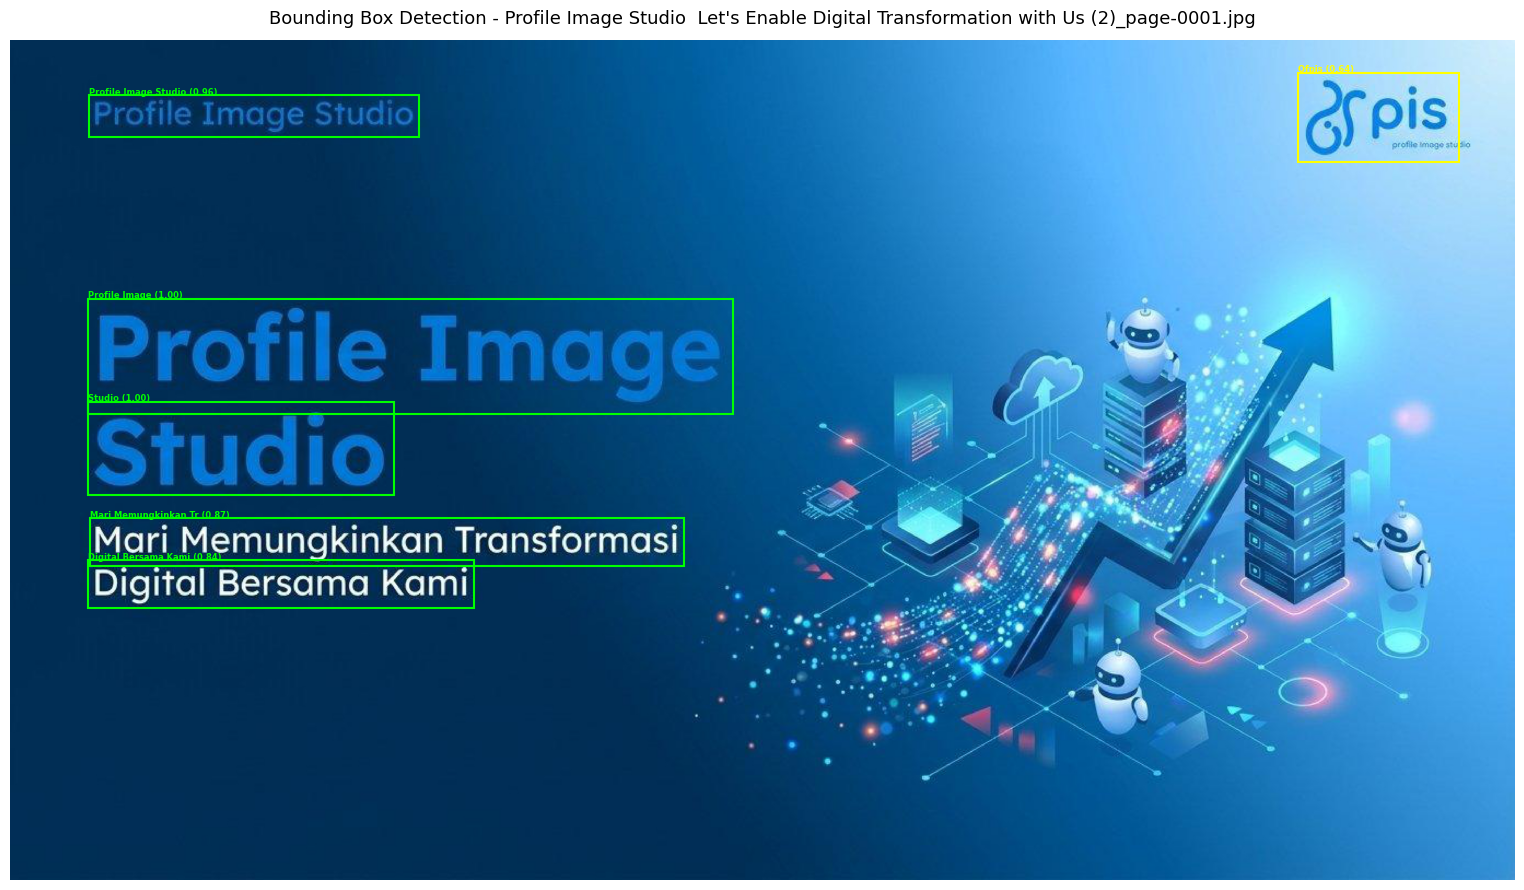

Visualization saved to output/


In [5]:
image_rgb = cv2.imread(str(slide_path))
image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)
h, w = image_rgb.shape[:2]

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.imshow(image_rgb)
ax.set_title(f'Bounding Box Detection - {slide_path.name}', fontsize=13, pad=12)
ax.axis('off')

for (points, text, confidence) in ocr_results:
    if confidence < 0.3:
        continue
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    x1, y1 = int(min(xs)), int(min(ys))
    bw, bh = int(max(xs)) - x1, int(max(ys)) - y1

    # Box color: green for high confidence, yellow for medium
    color = 'lime' if confidence > 0.7 else 'yellow'
    rect = patches.Rectangle((x1, y1), bw, bh,
                               linewidth=1.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 4, f'{text[:20]} ({confidence:.2f})',
            fontsize=6, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f'{slide_path.stem}_bbox_viz.jpg'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Visualization saved to output/')

### Extract Style (Color & Font Size)

In [6]:
from src.cv_pipeline.html_generator import extract_text_color, estimate_font_size

original_bgr = cv2.imread(str(slide_path))
print(f'Style analysis for {len(ocr_results)} elemen teks:\n')
print(f'{"No":<4} {"Text":<30} {"Color":<10} {"FontSz":<8} {"Conf":<6}')
print('-' * 62)

for i, (points, text, confidence) in enumerate(ocr_results):
    if confidence < 0.3:
        continue
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    bbox = (int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys)))

    color = extract_text_color(original_bgr, bbox)
    font_size = estimate_font_size(bbox)
    short_text = text[:28] + '..' if len(text) > 30 else text
    print(f'{i+1:<4} {short_text:<30} {color:<10} {font_size:<8} {confidence:.2f}')

Style analysis for 7 elemen teks:

No   Text                           Color      FontSz   Conf  
--------------------------------------------------------------
1    Profile Image Studio           #3E89C3    87       0.96
2    Ofpis                          #04529C    185      0.64
4    Profile Image                  #328CDD    242      1.00
5    Studio                         #3087D4    194      1.00
6    Mari Memungkinkan Transformasi #FFFFFD    100      0.87
7    Digital Bersama Kami           #FEFFFF    100      0.84


### Inpainting - Remove Text from Background (Bonus)

Running inpainting...


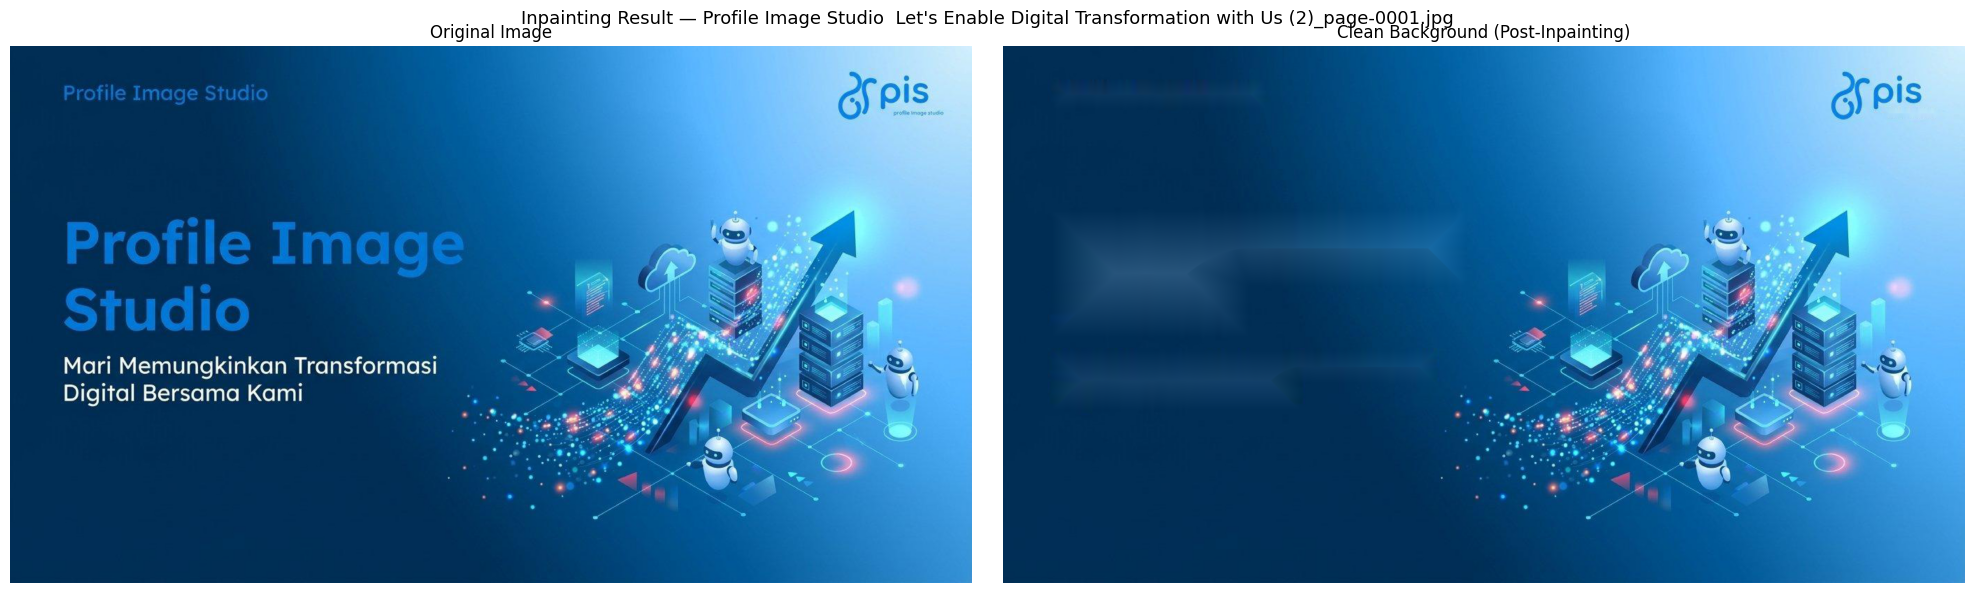

Clean background saved: d:\Produktif Backup\AI\Langraph\output\Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001_clean_bg.jpg


In [7]:
bboxes = easyocr_to_bboxes(ocr_results)
clean_bg_path = str(OUTPUT_DIR / f'{slide_path.stem}_clean_bg{slide_path.suffix}')

print('Running inpainting...')
clean_image, saved_path = remove_text_from_image(
    image_path=str(slide_path),
    bboxes=bboxes,
    output_path=clean_bg_path,
    dilate_px=5,
)

# Show comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(clean_image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Clean Background (Post-Inpainting)', fontsize=12)
axes[1].axis('off')

plt.suptitle(f'Inpainting Result — {slide_path.name}', fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f'{slide_path.stem}_inpaint_compare.jpg'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Clean background saved: {saved_path}')

### Generate HTML

In [8]:
output_html_path = str(OUTPUT_DIR / f'{slide_path.stem}_result.html')

print('Generating HTML...')
html_path = generate_html(
    original_image_path=str(slide_path),
    ocr_results=ocr_results,
    output_path=output_html_path,
    clean_background_path=clean_bg_path,  # background post-inpainting
    min_confidence=0.3,
)

print(f'HTML saved: {html_path}')
print('   Open file in browser to see the result!')
print('   Click text in browser to edit (contenteditable)')

Generating HTML...
HTML saved: d:\Produktif Backup\AI\Langraph\output\Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001_result.html
   Open file in browser to see the result!
   Click text in browser to edit (contenteditable)


### Batch Process All Slides

In [9]:
print(f'Batch processing {len(slide_files)} slide...\n')

results_summary = []

for idx, slide in enumerate(slide_files):
    print(f'[{idx+1}/{len(slide_files)}] Processing: {slide.name}')

    try:
        # OCR
        ocr = reader.readtext(str(slide))
        bboxes = easyocr_to_bboxes(ocr)

        # Inpainting
        clean_path = str(OUTPUT_DIR / f'{slide.stem}_clean_bg{slide.suffix}')
        _, clean_path = remove_text_from_image(
            image_path=str(slide),
            bboxes=bboxes,
            output_path=clean_path,
            dilate_px=5,
        )

        # HTML
        html_out = str(OUTPUT_DIR / f'{slide.stem}_result.html')
        generate_html(
            original_image_path=str(slide),
            ocr_results=ocr,
            output_path=html_out,
            clean_background_path=clean_path,
            min_confidence=0.3,
        )

        n_text = sum(1 for _, _, c in ocr if c >= 0.3)
        results_summary.append({'slide': slide.name, 'texts': n_text, 'html': html_out, 'status': ''})
        print(f'   → {n_text} texts, HTML: {Path(html_out).name}')

    except Exception as e:
        results_summary.append({'slide': slide.name, 'texts': 0, 'html': None, 'status': f'{e}'})
        print(f'   → ERROR: {e}')

print('\n' + '='*60)
print('BATCH PROCESSING SUMMARY')
print('='*60)
print(f'{"Slide":<45} {"Texts":<6} {"Status"}')
print('-'*60)
for r in results_summary:
    print(f'{r["slide"]:<45} {r["texts"]:<6} {r["status"]}')
print('='*60)
print(f'\nDone! Output saved in folder: {OUTPUT_DIR}')

Batch processing 5 slide...

[1/5] Processing: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001.jpg


d:\Produktif Backup\AI\Langraph\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   → 6 texts, HTML: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001_result.html
[2/5] Processing: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0002.jpg


d:\Produktif Backup\AI\Langraph\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   → 13 texts, HTML: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0002_result.html
[3/5] Processing: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0003.jpg


...

   → 21 texts, HTML: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0003_result.html
[4/5] Processing: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0004.jpg


d:\Produktif Backup\AI\Langraph\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   → 17 texts, HTML: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0004_result.html
[5/5] Processing: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0005.jpg


d:\Produktif Backup\AI\Langraph\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   → 12 texts, HTML: Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0005_result.html

BATCH PROCESSING SUMMARY
Slide                                         Texts  Status
------------------------------------------------------------
Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0001.jpg 6      
Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0002.jpg 13     
Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0003.jpg 21     
Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0004.jpg 17     
Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0005.jpg 12     

Done! Output saved in folder: d:\Produktif Backup\AI\Langraph\output


## Output Files

Each slide generates 3 files in the `output/` folder:

| File | Description |
|------|------|
| `*_bbox_viz.jpg` | OCR bounding box visualization |
| `*_clean_bg.jpg` | Clean background after inpainting |
| `*_result.html` | **Final HTML file** - open in browser, click text to edit |

### How to Open HTML
```
# From project root:
start output\slide_1_result.html
```